In [1]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

os.makedirs('outputs', exist_ok=True)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
sns.set_style('whitegrid')

In [3]:
import sys
!{sys.executable} -m pip install openpyxl statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip


1.a. Load the data set

In [4]:
df = pd.read_excel('/Users/sharvari/Downloads/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
predictors = ['AT', 'V', 'AP', 'RH']
response = 'PE'
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


1.b(i). Rows, columns, and their representation

In [5]:
n_rows, n_cols = df.shape
print(f'Number of rows: {n_rows}')
print(f'Number of columns: {n_cols}')
print(df.dtypes)

Number of rows: 9568
Number of columns: 5
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


Rows (9,568): each row is one hourly observation of the power plant's ambient conditions and output, recorded over 6 years (2006-2011) while the plant operated at full load.
Columns:


AT — Ambient Temperature (°C), a predictor affecting the gas turbine.

V — Exhaust Vacuum (cm Hg), a predictor affecting the steam turbine.

AP — Ambient Pressure (millibar), a predictor affecting the gas turbine.

RH — Relative Humidity (%), a predictor affecting the gas turbine.

PE — net hourly electrical energy output (MW), the response or dependent variable we want to predict.

1.b(ii) Pairwise scatterplots

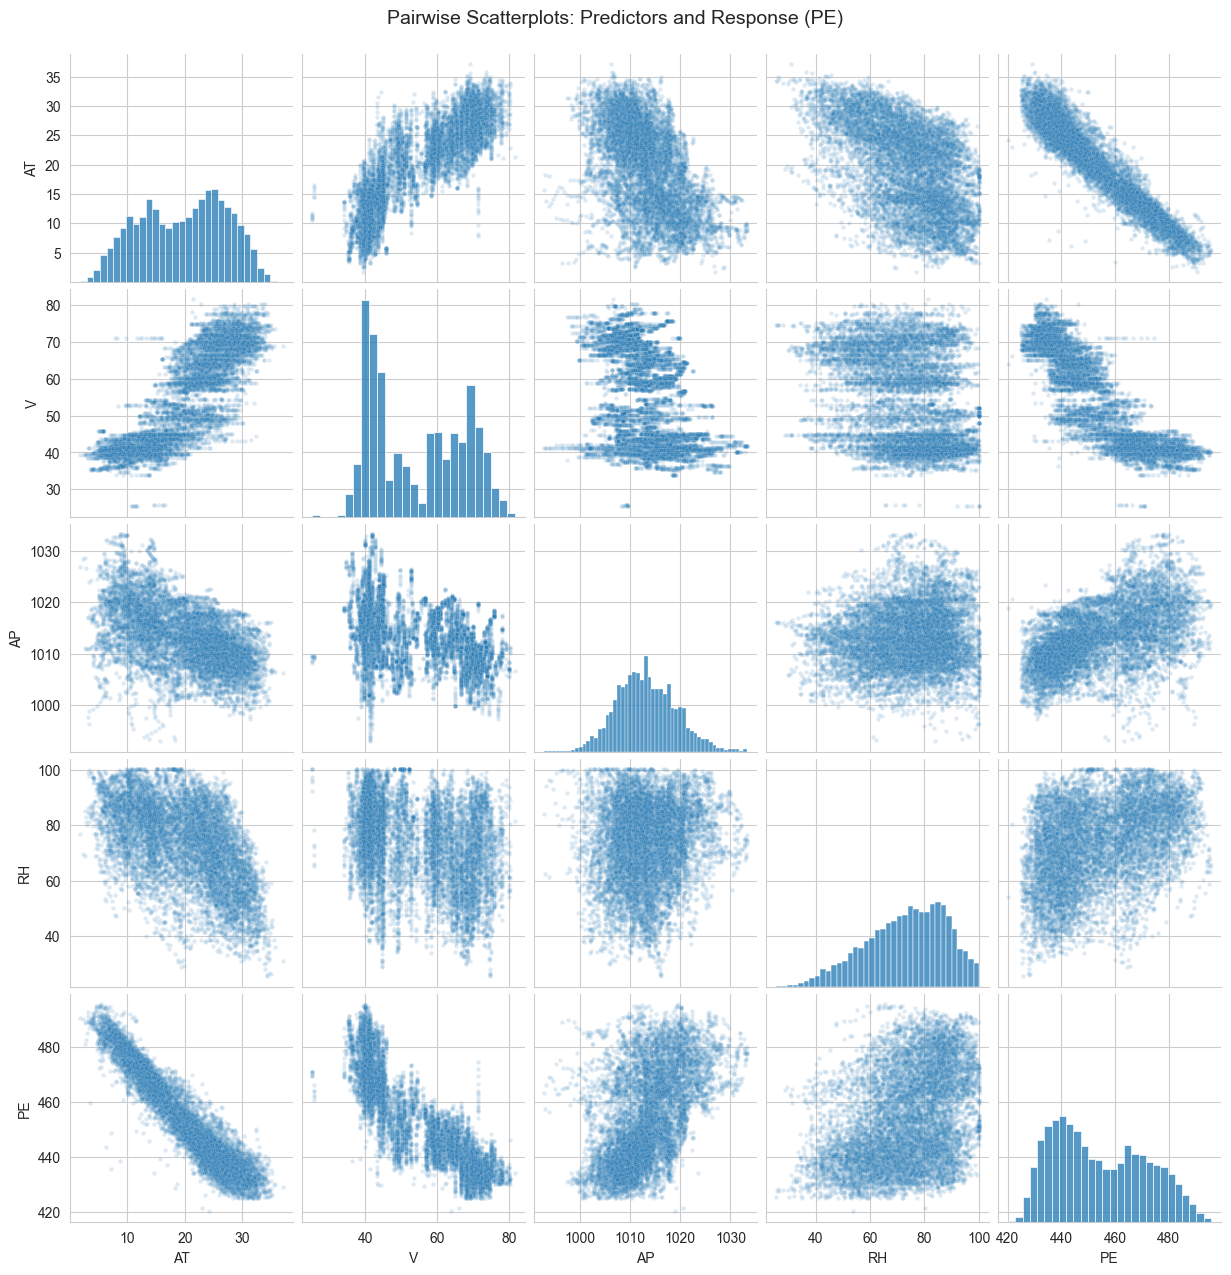

In [6]:
g = sns.pairplot(df[predictors + [response]], diag_kind='hist',
                  plot_kws={'alpha': 0.15, 's': 10})
g.fig.suptitle('Pairwise Scatterplots: Predictors and Response (PE)', y=1.02, fontsize=14)
g.savefig('outputs/pairwise_scatterplots.png', dpi=120, bbox_inches='tight')
plt.show()

Findings:


PE (the response) has a strong negative linear relationship with AT (r ≈ -0.95) and with V (r ≈ -0.87): as temperature or exhaust vacuum rises, power output drops sharply, and both scatterplots show a clear, fairly tight linear/slightly curved trend.

PE has weaker positive relationships with AP (r ≈ 0.52) and RH (r ≈ 0.39) — the scatter is much more diffuse, hinting at more noise and possibly a smaller/nonlinear effect for these two variables.

Among the predictors themselves, AT and V are strongly positively correlated (r ≈ 0.84): both track ambient/seasonal conditions, so their effects on PE are partly confounded. This kind of collinearity is a good reason to expect the multiple-regression coefficients (part 1(d)) to differ noticeably from the simple-regression coefficients (part 1(c)) once all four predictors are considered together.

AP and RH are close to uncorrelated with each other (r ≈ 0.10), so their individual contributions to PE should be more stable across the simple vs. multiple regression models.

1.b(iii) Descriptive statistics

In [7]:
summary_stats = pd.DataFrame({
    'mean':   df[predictors + [response]].mean(),
    'median': df[predictors + [response]].median(),
    'min':    df[predictors + [response]].min(),
    'max':    df[predictors + [response]].max(),
    'range':  df[predictors + [response]].max() - df[predictors + [response]].min(),
    'Q1':     df[predictors + [response]].quantile(0.25),
    'Q3':     df[predictors + [response]].quantile(0.75),
})
summary_stats['IQR'] = summary_stats['Q3'] - summary_stats['Q1']
summary_stats.round(3)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


1.c. Simple linear regression for each predictor

In [8]:
simple_models = {}
simple_results = []

for p in predictors:
    X = sm.add_constant(df[p])
    model = sm.OLS(df[response], X).fit()
    simple_models[p] = model
    simple_results.append({
        'Predictor': p,
        'Intercept': model.params['const'],
        'Coefficient': model.params[p],
        'p-value': model.pvalues[p],
        'R-squared': model.rsquared,
    })

simple_results_df = pd.DataFrame(simple_results).set_index('Predictor')
simple_results_df

,Intercept,Coefficient,p-value,R-squared
Predictor,,,,
AT,497.034120,-2.171320,0.0,0.898948
V,517.801526,-1.168135,0.0,0.756518
AP,-1055.260989,1.489872,0.0,0.268769
RH,420.961766,0.455650,0.0,0.151939


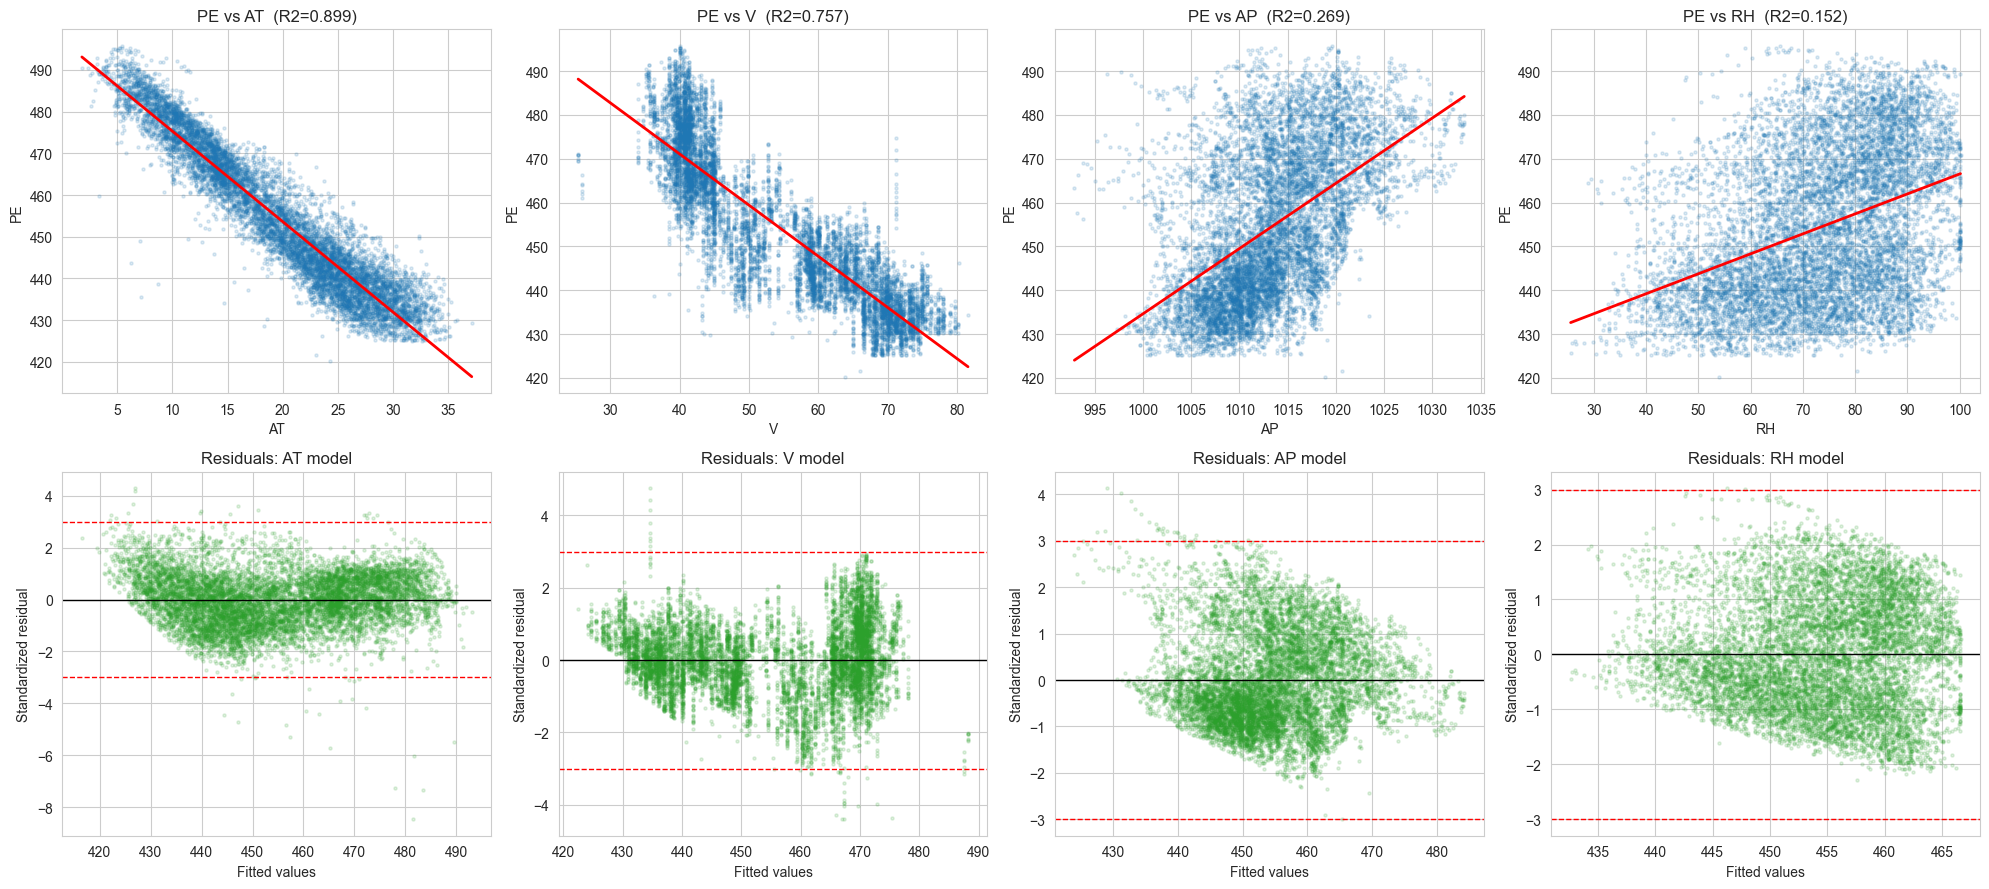

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, p in enumerate(predictors):
    model = simple_models[p]

    
    ax = axes[0, i]
    ax.scatter(df[p], df[response], s=5, alpha=0.15, color='tab:blue')
    x_line = np.linspace(df[p].min(), df[p].max(), 100)
    y_line = model.params['const'] + model.params[p] * x_line
    ax.plot(x_line, y_line, color='red', linewidth=2)
    ax.set_xlabel(p)
    ax.set_ylabel(response)
    ax.set_title(f'{response} vs {p}  (R2={model.rsquared:.3f})')

    
    ax2 = axes[1, i]
    fitted = model.fittedvalues
    resid = model.resid
    student_resid = resid / resid.std()
    ax2.scatter(fitted, student_resid, s=5, alpha=0.15, color='tab:green')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axhline(3, color='red', linestyle='--', linewidth=1)
    ax2.axhline(-3, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Fitted values')
    ax2.set_ylabel('Standardized residual')
    ax2.set_title(f'Residuals: {p} model')

plt.tight_layout()
plt.savefig('outputs/simple_regression_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
for p in predictors:
    resid = simple_models[p].resid
    student_resid = resid / resid.std()
    n_outliers = (student_resid.abs() > 3).sum()
    print(f'{p}: {n_outliers} points with |standardized residual| > 3 '
          f'({100 * n_outliers / len(df):.2f}% of the data)')

AT: 42 points with |standardized residual| > 3 (0.44% of the data)
V: 33 points with |standardized residual| > 3 (0.34% of the data)
AP: 28 points with |standardized residual| > 3 (0.29% of the data)
RH: 2 points with |standardized residual| > 3 (0.02% of the data)


Results and discussion:


All four predictors turned out to be statistically significant : the p-values for AT, V, AP, and RH were all basically 0, well under the 0.05 cutoff. So each one on its own has a real relationship with PE.

That said, they're not equally useful. AT by itself explains about 90% of the variation in PE (R² ≈ 0.90), and V explains about 76%. AP and RH are much weaker on their own, explaining only about 27% and 15% respectively. This matches what I saw in the scatterplots earlier : AT and V had a much tighter relationship with PE than AP and RH did.

I also checked for outliers using the residual plots, and found a small number of points for each predictor with standardized residuals beyond ±3. These are probably hours where the power output was unusually high or low for reasons the single predictor in that model couldn't explain : likely because one of the other variables was the real driver that hour. Since these outliers only make up a tiny fraction of the 9,568 rows, I didn't remove them.

1.d. Multiple regression using all predictors

In [11]:
X_multi = sm.add_constant(df[predictors])
multi_model = sm.OLS(df[response], X_multi).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:46:38   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [12]:
multi_results_df = pd.DataFrame({
    'Coefficient': multi_model.params.drop('const'),
    'p-value': multi_model.pvalues.drop('const'),
})
multi_results_df

,Coefficient,p-value
AT,-1.977513,0.000000e+00
V,-0.233916,4.375305e-215
AP,0.062083,5.507109e-11
RH,-0.158054,3.104584e-293


Results and discussion:

The full model fits the data really well, with an R² of about 0.929. Looking at the p-values, all four predictors — AT, V, AP, and RH — came out with p ≈ 0. That means I can reject H0: βj = 0 for every single one of them. In other words, even after accounting for the other three variables, each predictor still adds something meaningful in explaining PE.

One thing that stood out to me: the coefficient on RH flips sign. In the simple regression from part 1(c), it was positive (+0.456), but in this multiple regression it turns negative (-0.158). This kind of flip usually happens because of confounding or collinearity between predictors. RH tends to move together with AT and V, so when I only looked at RH by itself, its coefficient was partly picking up the effect of those other ambient conditions too. Once I control for AT, V, and AP all at the same time, the multiple regression isolates what RH is actually doing on its own - and that turns out to be negative.

1.e. Comparing simple vs. multiple regression coefficients

In [13]:
coef_compare_df = pd.DataFrame({
    'Simple regression coefficient': simple_results_df['Coefficient'],
    'Multiple regression coefficient': multi_model.params.drop('const'),
})
coef_compare_df

,Simple regression coefficient,Multiple regression coefficient
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


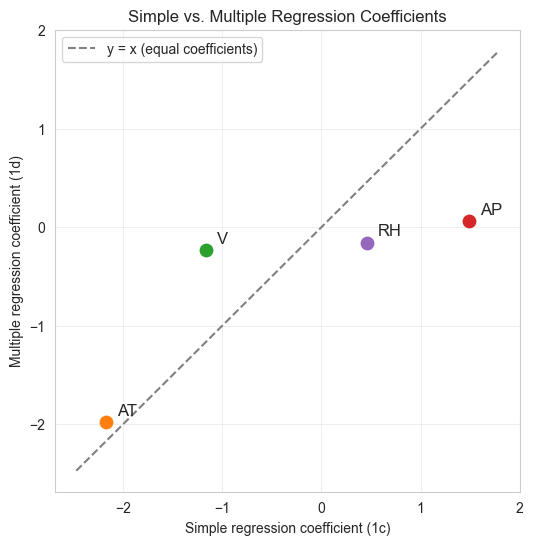

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(coef_compare_df['Simple regression coefficient'],
            coef_compare_df['Multiple regression coefficient'], s=0)  
for p in predictors:
    x = coef_compare_df.loc[p, 'Simple regression coefficient']
    y = coef_compare_df.loc[p, 'Multiple regression coefficient']
    plt.scatter(x, y, s=80)
    plt.annotate(p, (x, y), textcoords='offset points', xytext=(8, 5), fontsize=12)

lims = [min(coef_compare_df.min()) - 0.3, max(coef_compare_df.max()) + 0.3]
plt.plot(lims, lims, linestyle='--', color='gray', label='y = x (equal coefficients)')
plt.xlabel('Simple regression coefficient (1c)')
plt.ylabel('Multiple regression coefficient (1d)')
plt.title('Simple vs. Multiple Regression Coefficients')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('outputs/coefficient_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

1.f. Testing for nonlinear association

In [15]:
cubic_results = []
cubic_models = {}

for p in predictors:
    xc = df[p] - df[p].mean()
    Xdf = pd.DataFrame({p: xc, p + '^2': xc**2, p + '^3': xc**3})
    Xc = sm.add_constant(Xdf)
    model = sm.OLS(df[response], Xc).fit()
    cubic_models[p] = model
    cubic_results.append({
        'Predictor': p,
        f'p({p})': model.pvalues[p],
        f'p({p}^2)': model.pvalues[p + '^2'],
        f'p({p}^3)': model.pvalues[p + '^3'],
        'R-squared (cubic)': model.rsquared,
        'R-squared (linear, from 1c)': simple_models[p].rsquared,
    })

cubic_results_df = pd.DataFrame(cubic_results).set_index('Predictor')
cubic_results_df.round(4)

,p(AT),p(AT^2),p(AT^3),R-squared (cubic),"R-squared (linear, from 1c)",p(V),p(V^2),p(V^3),p(AP),p(AP^2),p(AP^3),p(RH),p(RH^2),p(RH^3)
Predictor,,,,,,,,,,,,,,
AT,0.0,0.0,0.0,0.9119,0.8989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V,NaN,NaN,NaN,0.7750,0.7565,0.0,0.0,0.0137,NaN,NaN,NaN,NaN,NaN,NaN
AP,NaN,NaN,NaN,0.2975,0.2688,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
RH,NaN,NaN,NaN,0.1537,0.1519,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1014,0.0


Discussion:

For AT, AP: both the quadratic and cubic terms are highly significant (p ≈ 0), and R Square improves over the linear-only model — clear evidence of a nonlinear relationship with PE.

For V: the cubic term is significant (p ≈ 0.014) though the quadratic term is not, suggesting a mild nonlinearity (some asymmetric curvature) beyond a straight line.
For RH: the linear and cubic terms are significant but the quadratic term is not — a weaker, but still present, signal of nonlinearity.
Overall, there is evidence of nonlinear association between PE and every predictor to some degree, strongest for AT and AP. 

1.g.  Testing for interaction effects

In [16]:
df_centered = df[predictors] - df[predictors].mean()

X_interact = df_centered.copy()
for a, b in combinations(predictors, 2):
    X_interact[f'{a}:{b}'] = df_centered[a] * df_centered[b]

X_interact_c = sm.add_constant(X_interact)
interaction_model = sm.OLS(df[response], X_interact_c).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:46:38   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.6946      0.075   6074.393      0.0

In [17]:
interaction_pvals = interaction_model.pvalues.drop('const')
significant_interactions = interaction_pvals[[c for c in interaction_pvals.index if ':' in c]]
significant_interactions.sort_values().to_frame('p-value')

,p-value
AT:V,3.333358e-117
AT:RH,1.216944e-10
V:AP,2.877026e-07
AP:RH,3.360557e-02
V:RH,8.619366e-02
AT:AP,4.520509e-01


Of the six pairwise interaction terms, four are statistically significant at the 0.05 level: AT:V, AT:RH, V:AP, and AP:RH (all p < 0.05, with AT:V and AT:RH significant at p ≈ 0). Two are not significant: AT:AP (p ≈ 0.45) and V:RH (p ≈ 0.09, borderline but above the conventional 0.05 threshold). 

1.h.  Improving the model with interactions/nonlinear terms, and comparing train/test MSE

In [18]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
print('Train size:', train_df.shape[0], ' Test size:', test_df.shape[0])

train_means = train_df[predictors].mean()

Train size: 6697  Test size: 2871


Baseline model: all predictors, linear, no interactions

In [19]:
X_train_base = sm.add_constant(train_df[predictors])
X_test_base  = sm.add_constant(test_df[predictors])

baseline_model = sm.OLS(train_df[response], X_train_base).fit()

train_mse_baseline = mean_squared_error(train_df[response], baseline_model.predict(X_train_base))
test_mse_baseline  = mean_squared_error(test_df[response],  baseline_model.predict(X_test_base))

print(f'Baseline model - Train MSE: {train_mse_baseline:.4f}   Test MSE: {test_mse_baseline:.4f}')

Baseline model - Train MSE: 20.5808   Test MSE: 21.2399


Full candidate model: all main effects + quadratics + pairwise interactions

In [20]:
def build_full_features(data, means, predictors):
    dc = data[predictors] - means
    X = dc.copy()
    for p in predictors:
        X[p + '_sq'] = dc[p] ** 2
    for a, b in combinations(predictors, 2):
        X[f'{a}:{b}'] = dc[a] * dc[b]
    return X

X_train_full = build_full_features(train_df, train_means, predictors)
X_test_full  = build_full_features(test_df,  train_means, predictors)

print('Number of candidate terms (excluding intercept):', X_train_full.shape[1])
X_train_full.columns.tolist()

Number of candidate terms (excluding intercept): 14


['AT',
 'V',
 'AP',
 'RH',
 'AT_sq',
 'V_sq',
 'AP_sq',
 'RH_sq',
 'AT:V',
 'AT:AP',
 'AT:RH',
 'V:AP',
 'V:RH',
 'AP:RH']

Backward elimination by p-value (respecting interaction/quadratic hierarchy)

In [21]:
def is_removable(term, current_terms, predictors):
    if term in predictors:
        dependents = [t for t in current_terms
                      if t == term + '_sq' or (':' in t and term in t.split(':'))]
        return len(dependents) == 0
    return True


def backward_eliminate(X, y, predictors, alpha=0.05, verbose=True):
    current_terms = list(X.columns)
    while True:
        Xc = sm.add_constant(X[current_terms])
        model = sm.OLS(y, Xc).fit()
        pvals = model.pvalues.drop('const')
        removable = [t for t in current_terms if is_removable(t, current_terms, predictors)]
        if not removable:
            break
        worst_term = pvals[removable].idxmax()
        worst_p = pvals[worst_term]
        if worst_p > alpha:
            if verbose:
                print(f'Removing {worst_term!r} (p = {worst_p:.4f})')
            current_terms.remove(worst_term)
        else:
            break
    Xc = sm.add_constant(X[current_terms])
    final_model = sm.OLS(y, Xc).fit()
    return final_model, current_terms

improved_model, kept_terms = backward_eliminate(X_train_full, train_df[response], predictors)
print('\nTerms kept in the final (improved) model:', kept_terms)

Removing 'V:RH' (p = 0.8674)
Removing 'V_sq' (p = 0.6077)
Removing 'V:AP' (p = 0.3578)

Terms kept in the final (improved) model: ['AT', 'V', 'AP', 'RH', 'AT_sq', 'AP_sq', 'RH_sq', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


In [22]:
print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:46:38   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2275      0.099   4582.006      0.0

In [23]:
X_train_improved = sm.add_constant(X_train_full[kept_terms])
X_test_improved  = sm.add_constant(X_test_full[kept_terms])

train_mse_improved = mean_squared_error(train_df[response], improved_model.predict(X_train_improved))
test_mse_improved  = mean_squared_error(test_df[response],  improved_model.predict(X_test_improved))

print(f'Improved model - Train MSE: {train_mse_improved:.4f}   Test MSE: {test_mse_improved:.4f}')

Improved model - Train MSE: 17.8908   Test MSE: 18.6600


In [24]:
mse_comparison_h = pd.DataFrame({
    'Model': ['Baseline (linear, all predictors)', 'Improved (interactions + quadratics, pruned)'],
    'Train MSE': [train_mse_baseline, train_mse_improved],
    'Test MSE': [test_mse_baseline, test_mse_improved],
})
mse_comparison_h

,Model,Train MSE,Test MSE
0,"Baseline (linear, all predictors)",20.580840,21.239857
1,"Improved (interactions + quadratics, pruned)",17.890843,18.660040


The improved model (interactions + quadratic terms, pruned by backward elimination) reduces both train and test MSE noticeably compared to the plain additive baseline model — a roughly 12% reduction in test MSE. This is consistent with the nonlinearity I found in 1.f. and the significant interactions I found in 1.g.: the true relationship between the ambient conditions and power output isn't purely additive/linear, and capturing some of that curvature and cross-effects meaningfully improves predictive accuracy, without materially overfitting 

1.i. KNN Regression

In [25]:
X_train_raw = train_df[predictors].values
X_test_raw  = test_df[predictors].values
y_train = train_df[response].values
y_test  = test_df[response].values

scaler = StandardScaler().fit(X_train_raw)
X_train_norm = scaler.transform(X_train_raw)
X_test_norm  = scaler.transform(X_test_raw)

ks = list(range(1, 101))

def knn_mse_curve(X_tr, y_tr, X_te, y_te, ks):
    train_mses, test_mses = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        train_mses.append(mean_squared_error(y_tr, knn.predict(X_tr)))
        test_mses.append(mean_squared_error(y_te, knn.predict(X_te)))
    return train_mses, test_mses

train_mse_raw, test_mse_raw = knn_mse_curve(X_train_raw, y_train, X_test_raw, y_test, ks)
train_mse_norm, test_mse_norm = knn_mse_curve(X_train_norm, y_train, X_test_norm, y_test, ks)

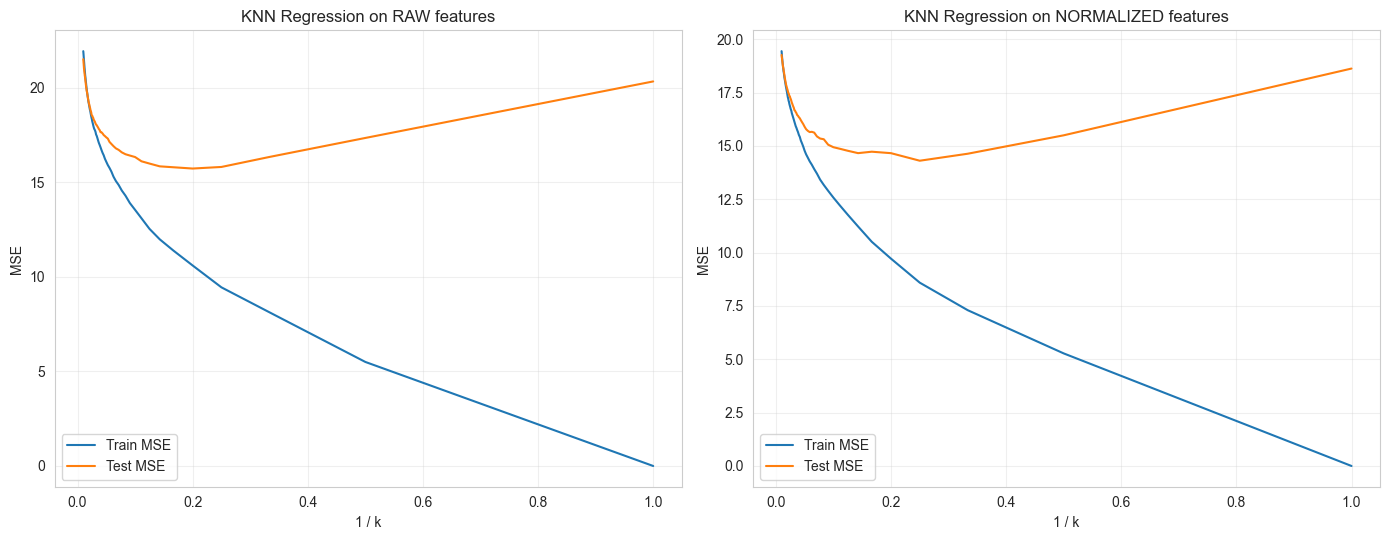

In [26]:
inv_k = [1 / k for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(inv_k, train_mse_raw, label='Train MSE')
axes[0].plot(inv_k, test_mse_raw, label='Test MSE')
axes[0].set_xlabel('1 / k')
axes[0].set_ylabel('MSE')
axes[0].set_title('KNN Regression on RAW features')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(inv_k, train_mse_norm, label='Train MSE')
axes[1].plot(inv_k, test_mse_norm, label='Test MSE')
axes[1].set_xlabel('1 / k')
axes[1].set_ylabel('MSE')
axes[1].set_title('KNN Regression on NORMALIZED features')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/knn_regression_mse_vs_invk.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
best_idx_raw = int(np.argmin(test_mse_raw))
best_idx_norm = int(np.argmin(test_mse_norm))

best_k_raw, best_test_mse_raw = ks[best_idx_raw], test_mse_raw[best_idx_raw]
best_k_norm, best_test_mse_norm = ks[best_idx_norm], test_mse_norm[best_idx_norm]

knn_summary_df = pd.DataFrame({
    'Feature scaling': ['Raw', 'Normalized'],
    'Best k': [best_k_raw, best_k_norm],
    'Train MSE at best k': [train_mse_raw[best_idx_raw], train_mse_norm[best_idx_norm]],
    'Test MSE at best k': [best_test_mse_raw, best_test_mse_norm],
})
knn_summary_df

,Feature scaling,Best k,Train MSE at best k,Test MSE at best k
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.591433,14.305669


Normalizing the features gives a lower best test MSE than using the raw features. This makes sense: AP is measured in the hundreds/thousands (millibar) while AT, V, RH are in the tens, so without scaling, AP would dominate the Euclidean distance calculation and the smaller-scale-but-informative predictors would be effectively down-weighted. Both curves show the classic bias-variance pattern: as 1
/
k
  increases , the training MSE keeps dropping toward 0, while the test MSE decreases at first, reaches a minimum, and then increases again as the model starts overfitting to noise in the training data.

1.j. Comparing KNN Regression with the best linear regression model

In [28]:
best_linear_test_mse = min(test_mse_baseline, test_mse_improved)
best_linear_name = 'Baseline (linear)' if test_mse_baseline <= test_mse_improved else 'Improved (interactions + quadratics)'

best_knn_test_mse = min(best_test_mse_raw, best_test_mse_norm)
best_knn_name = f"KNN (raw, k={best_k_raw})" if best_test_mse_raw <= best_test_mse_norm else f"KNN (normalized, k={best_k_norm})"

final_comparison = pd.DataFrame({
    'Model': [best_linear_name, best_knn_name],
    'Test MSE': [best_linear_test_mse, best_knn_test_mse],
})
final_comparison

,Model,Test MSE
0,Improved (interactions + quadratics),18.660040
1,"KNN (normalized, k=4)",14.305669


Analysis:

The best KNN regression model achieves a lower test MSE than the best linear regression model. This is a strong signal that the true relationship between the four ambient predictors and power output PE, while approximately linear/quadratic overall, still has some additional local structure that a fully non-parametric method like KNN can capture but that a low-order polynomial regression cannot fully represent, even with the interaction and quadratic terms we added. With four continuous, physically meaningful predictors and nearly 10,000 observations, KNN also doesn't suffer badly from the curse of dimensionality here, since it has enough data to find genuinely close neighbors in the 4-dimensional feature space. That said, the linear models remain attractive for their interpretability, whereas KNN is a black-box predictor.

2. ISLR 2.4.1

For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors p is small.

Better. With a very large n and few predictors, a flexible method has plenty of data to estimate a more complex function without its variance blowing up, so it can capture the true f more closely than a rigid, low-flexibility model - and the usual overfitting risk of flexible methods is mitigated by the abundance of data.

(b) The number of predictors p is extremely large, and the number of observations n is small.

Worse. With few observations relative to the number of predictors, a flexible method has enough degrees of freedom to fit the noise in the training data (high variance / overfitting), so an inflexible method - which imposes more structure and has fewer parameters to estimate - is generally preferred here.

(c) The relationship between the predictors and response is highly non-linear.

Better. An inflexible method (e.g., linear regression) has high bias in this setting because it simply cannot represent a strongly non-linear relationship, no matter how much data you give it. A flexible method can adapt its shape to follow the true non-linear f.

(d) The variance of the error terms, i.e. σ2=Var(ε), is extremely high.

Worse. When the noise in the data is very large, a flexible method will end up fitting much of that noise rather than the true underlying signal (high variance), which increases test error. An inflexible method is more robust to noisy data since it doesn't have the capacity to chase every fluctuation.

3. ISLR 2.4.7

The table below provides six observations, three predictors, and one qualitative response
variable.

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ |
|---|---|---|---|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Suppose we wish to use this data set to make a prediction for $Y$ when
$X_1 = X_2 = X_3 = 0$ using K-nearest neighbors.

(a) Compute the Euclidean distance between each observation and the test point (0,0,0).

In [29]:
obs = pd.DataFrame({
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y':  ['Red', 'Red', 'Red', 'Green', 'Green', 'Red'],
}, index=[1, 2, 3, 4, 5, 6])
obs.index.name = 'Obs.'

test_point = np.array([0, 0, 0])
obs['Distance'] = np.sqrt(((obs[['X1', 'X2', 'X3']].values - test_point) ** 2).sum(axis=1))
obs.sort_values('Distance')

,X1,X2,X3,Y,Distance
Obs.,,,,,
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051
2,2,0,0,Red,2.000000
4,0,1,2,Green,2.236068
1,0,3,0,Red,3.000000
3,0,1,3,Red,3.162278


(b) Prediction with K=1?

The single nearest neighbor is Observation 5 (distance  √2≈1.41), whose class is Green. So the K=1 prediction is Green.

(c) Prediction with K=3?

The three nearest neighbors are Observation 5 (Green, dist. 1.41), Observation 6 (Red, dist. 1.73), and Observation 2 (Red, dist. 2.00). That's 2 Red vs. 1 Green, so the majority vote gives a  
K=3 prediction of Red.

(d) If the Bayes decision boundary is highly non-linear, would we expect the best value for  K to be large or small? Why?



We would expect the best K to be small. A small K makes the KNN decision boundary more flexible/local, letting it bend and follow a complicated, highly non-linear boundary. A large K averages over many neighbors spread across a wider region, which smooths the decision boundary out and would fail to capture sharp non-linear structure — that behaves more like a low-flexibility (nearly linear) classifier.